### <b> PROJECT TITLE: </b>
`Aviation disruption Around the war zone during Iran US war - 2026`

### <b> INTRODUCTION: </b>
The global civil aviation sector experienced significant disruptions in February due to the conflict between the United States and Iran. These disruptions affected `airline operations, airport activities, and international air routes` across many countries. The dataset used in this project contains `multiple tables` that document the impacts of this event, including financial losses in the aviation sector, airport disruptions in 35 countries, airspace closures in 25 countries, and flight cancellations and rerouting in more than 40 countries.

This dataset provides opportunities for both predictive modeling and data analysis. `Several outcomes can be predicted`, such as estimated financial losses, flight cancellations, delay durations, airspace closure severity, and the number of passengers impacted. In this project, machine learning techniques will be used to predict estimated financial loss, flight cancellations, passenger impact, and overall aviation disruption patterns. The goal is to better understand the extent of global aviation disruptions and `identify key factors influencing these impacts`.

### <b> PROBLEM STATEMENT:</b>
This project analyzes how a geopolitical conflict can affect international airspace, airport and airline operations, and cause economic losses far beyond the actual battleground. Such disruptions create operational challenges for aviation authorities and airline companies, making it difficult to anticipate and effectively manage their impacts. The results will help identify the key factors that contribute to aviation disruptions and provide insights that support improved decision‑making and preparedness for future aviation crises.

### <b> OBJECTIVES: </b>
* `Collect and pre-processing` aviation disruption datasets. <br>
* Conduct`EDA` for airloss and passenger affected. <br>
* `Predict` estimated losses across multiple countries. <br>
* Predict flight cancellation due to airport closures. <br>
* `Building model` to classify the severity of the aviation disruption in different regions. <br>
* `Visualize` prediction and disruption patterns on `maps` to provide clear geographical insights. <br>

### <b> METHODOLOGY: </b>

#### <b> Data preprocessing: </b>
<b> Note: </b> A `Data Overview` can be find at the end of the documentation.

* `Merging` multi-table dataset
* Handling `date and time` and encoding categorical variables
* Feature engineering(no.of.flights,airspace closure etc.)

####  <b> Model development: </b>

* `Regression models` for estimated loss and passenger impacted <br>
* `classification models` for flight cancellations and disruption severity <br>
* Model evaluations will use metrics such as `RMSE, R square,accuracy`.<br>

#### <b> Visualization: </b>

* Bubble maps using matplotlib/plotly to show flight cancellation, estimation loss <br>
* `HeatMaps` using seaborn to visualize disruption severity

####  <b> Analysis: </b>
* Identifying key factors influencing aviation disruption
* Providing insights for decision making

### <b> TOOLS AND TECHNOLOGIES: </b>

`Programming Language:` Python <br>
`Libraries:` Matplotlib, Numpy,Pandas, Seaborn, scikit-learn <br>
`visualization :` Bubble map, heat map <br>  

In [310]:
# Libraries 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# for axis ticker
import matplotlib.ticker as ticker

#import scikit-learn's OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
# Splitting data for train and test
from sklearn.model_selection import train_test_split
#scales feature
from sklearn.preprocessing import StandardScaler
# models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
# model evaluation
from sklearn.metrics import mean_squared_error,r2_score
#pylot for map
import plotly.express as px



In [311]:
# reading the files

base_file ="AviationData/"

airline_losses = pd.read_csv(base_file + "airline_losses.csv",index_col=0)
airport_disruption = pd.read_csv(base_file + "airport_disruptions.csv",index_col=0)
flight_cancellation = pd.read_csv(base_file + "flight_cancellations.csv",index_col=0)
flight_reroutes = pd.read_csv(base_file + "flight_reroutes.csv",index_col=0)
conflict_events = pd.read_csv(base_file+'conflict_events.csv',index_col=0)

df = {
    "Airlosses" : airline_losses,
    "Airport disruption" : airport_disruption,
    "Flight cancellation" : flight_cancellation,
    "Flight rerouted" : flight_reroutes,
    "Conflict Events" : conflict_events
}


for key,table in df.items():
    print("="*200)
    print(key)
    print("="*200)
    print(f'\nshape : {table.shape[0]}rows x {table.shape[1]}columns')
    print(f'\nColumns:\n {list(table.columns)}')
    print(f'\nDatatypes:\n{table.dtypes}')
    missing_value = table.isna().sum()
    if missing_value.sum() > 0:
        print(f"✅ {key} has missing value")
    else:
        print(f"❌ {key} No missing value")
    print("\nFirst 5 rows: ")
    display(table.head())
   

Airlosses

shape : 33rows x 7columns

Columns:
 ['country', 'airline_type', 'estimated_loss_usd', 'cancellations_count', 'reroutes_count', 'revenue_loss_pct', 'region']

Datatypes:
country                 object
airline_type            object
estimated_loss_usd     float64
cancellations_count      int64
reroutes_count           int64
revenue_loss_pct       float64
region                  object
dtype: object
❌ Airlosses No missing value

First 5 rows: 


,country,airline_type,estimated_loss_usd,cancellations_count,reroutes_count,revenue_loss_pct,region
airline,,,,,,,
Saudi Arabian Airlines,Saudi Arabia,Flag Carrier,943490000.0,171,35,39.0,Middle East
Etihad Airways,UAE,Flag Carrier,883530000.0,169,93,35.0,Middle East
flydubai,UAE,Low Cost,858190000.0,174,24,20.4,Middle East
Oman Air,Oman,Flag Carrier,837630000.0,135,38,26.7,Middle East
Air Arabia,UAE,Low Cost,762000000.0,75,26,30.5,Middle East


Airport disruption

shape : 113rows x 8columns

Columns:
 ['iata_code', 'country', 'region', 'disruption_type', 'severity_level', 'flights_affected', 'duration_hours', 'date']

Datatypes:
iata_code            object
country              object
region               object
disruption_type      object
severity_level       object
flights_affected      int64
duration_hours      float64
date                 object
dtype: object
❌ Airport disruption No missing value

First 5 rows: 


,iata_code,country,region,disruption_type,severity_level,flights_affected,duration_hours,date
airport_name,,,,,,,,
Beirut-Rafic Hariri International Airport,BEY,Lebanon,Middle East,Security Lockdown,High,177,66.5,2026-02-27
Damascus International Airport,DAM,Syria,Middle East,Full Closure,Critical,150,54.6,2026-02-27
Queen Alia International Airport,AMM,Jordan,Middle East,Security Lockdown,Critical,150,51.4,2026-02-28
Damascus International Airport,DAM,Syria,Middle East,Fuel Shortage,Critical,150,67.4,2026-02-28
Bahrain International Airport,BAH,Bahrain,Middle East,Flight Cancellations,Critical,150,41.2,2026-02-28


Flight cancellation

shape : 680rows x 9columns

Columns:
 ['airline', 'flight_number', 'origin', 'destination', 'origin_country', 'destination_country', 'aircraft_type', 'passengers_affected', 'reason']

Datatypes:
airline                object
flight_number          object
origin                 object
destination            object
origin_country         object
destination_country    object
aircraft_type          object
passengers_affected     int64
reason                 object
dtype: object
❌ Flight cancellation No missing value

First 5 rows: 


,airline,flight_number,origin,destination,origin_country,destination_country,aircraft_type,passengers_affected,reason
date,,,,,,,,,
2026-02-27,Ethiopian Airlines,ET3629,Riyadh,London,Saudi Arabia,UK,Boeing 777-300ER,206,Crew safety — company policy
2026-02-27,Cathay Pacific,CA4629,Cairo,Dubai,Egypt,UAE,Boeing 737 MAX 8,192,Crew safety — company policy
2026-02-27,flydubai,FL4492,Singapore,London,Singapore,UK,Boeing 777-300ER,403,Security risk — conflict zone
2026-02-27,KLM,KL2868,Cairo,Kuwait City,Egypt,Kuwait,Boeing 737 MAX 8,216,Government travel ban
2026-02-27,British Airways,BR3634,Riyadh,London,Saudi Arabia,UK,Boeing 777-300ER,225,Airspace closure — NOTAM


Flight rerouted

shape : 420rows x 11columns

Columns:
 ['airline', 'flight_number', 'origin', 'destination', 'original_route', 'new_route', 'original_distance_km', 'new_distance_km', 'additional_distance_km', 'extra_fuel_cost_usd', 'delay_hours']

Datatypes:
airline                    object
flight_number              object
origin                     object
destination                object
original_route             object
new_route                  object
original_distance_km        int64
new_distance_km             int64
additional_distance_km      int64
extra_fuel_cost_usd       float64
delay_hours               float64
dtype: object
❌ Flight rerouted No missing value

First 5 rows: 


,airline,flight_number,origin,destination,original_route,new_route,original_distance_km,new_distance_km,additional_distance_km,extra_fuel_cost_usd,delay_hours
date,,,,,,,,,,,
2026-02-28,Iran Air,IR9334,Los Angeles,Doha,Via Iran/Iraq corridor,Via Turkey–Kazakhstan northern route,4239,5887,1648,6633.95,4.5
2026-02-28,Turkish Airlines,TU7911,Paris,Dubai,Direct Tehran overfly,Via Ashgabat–Almaty route,6888,8697,1809,9543.08,3.1
2026-02-28,Turkish Airlines,TU907,London,Doha,Direct Gulf route,Via Jordan–Egypt alternate,11403,12416,1013,4268.36,4.2
2026-02-28,Air France,AI2443,Tehran,Istanbul,Via Persian Gulf,Via Indian Ocean southern route,7180,9863,2683,12945.15,2.1
2026-02-28,KLM,KL8000,Lahore,Doha,Via Strait of Hormuz,Via Red Sea–Suez route,6222,7574,1352,9305.36,3.1


Conflict Events

shape : 32rows x 5columns

Columns:
 ['event_type', 'event_description', 'location', 'severity', 'aviation_impact']

Datatypes:
event_type           object
event_description    object
location             object
severity             object
aviation_impact      object
dtype: object
❌ Conflict Events No missing value

First 5 rows: 


,event_type,event_description,location,severity,aviation_impact
date,,,,,
2025-12-15,Political,Widespread anti-government protests erupt acro...,"Tehran, Iran",High,Minimal — early warning signs only
2026-01-10,Diplomatic,UN Security Council emergency session on Iran ...,"New York, USA",Medium,Airlines begin monitoring situation
2026-01-25,Military,US deploys additional carrier strike group to ...,Persian Gulf,High,Airlines issue internal risk advisories
2026-02-05,Diplomatic,Geneva nuclear talks begin — mediated by Oman ...,"Geneva, Switzerland",Medium,Brief de-escalation — normal flight ops
2026-02-14,Political,Iran announces uranium enrichment to 90% — tal...,"Tehran, Iran",Very High,Airlines begin contingency route planning


In [312]:
for key,table in df.items():
    print("="*200)
    print(f'📊{key} data')
    print("="*200)
    display(table.describe())
print("="*200) 

📊Airlosses data


,estimated_loss_usd,cancellations_count,reroutes_count,revenue_loss_pct
count,3.300000e+01,33.000000,33.000000,33.000000
mean,2.622706e+08,68.272727,37.666667,17.172727
std,3.163496e+08,54.750156,27.157718,13.026374
min,1.033000e+07,6.000000,8.000000,3.000000
25%,3.452000e+07,26.000000,20.000000,6.400000
50%,5.284000e+07,50.000000,27.000000,9.600000
75%,4.478600e+08,120.000000,46.000000,26.700000
max,9.434900e+08,174.000000,99.000000,44.300000


📊Airport disruption data


,flights_affected,duration_hours
count,113.000000,113.000000
mean,168.362832,37.615929
std,74.013640,19.526015
min,21.000000,2.200000
25%,112.000000,24.000000
50%,150.000000,34.800000
75%,234.000000,53.900000
max,300.000000,71.800000


📊Flight cancellation data


,passengers_affected
count,680.000000
mean,261.288235
std,103.691180
min,80.000000
25%,174.750000
50%,258.500000
75%,344.250000
max,450.000000


📊Flight rerouted data


,original_distance_km,new_distance_km,additional_distance_km,extra_fuel_cost_usd,delay_hours
count,420.000000,420.000000,420.000000,420.000000,420.000000
mean,7154.092857,8634.152381,1480.059524,7644.440024,2.773571
std,2882.105466,3004.427422,656.077044,3723.005740,1.290387
min,2006.000000,2855.000000,410.000000,1593.400000,0.500000
25%,4692.750000,6101.250000,1007.750000,4819.865000,1.700000
50%,6995.000000,8699.500000,1345.000000,6763.225000,2.700000
75%,9762.500000,11292.500000,1823.250000,9654.825000,3.900000
max,11996.000000,15301.000000,3497.000000,19759.970000,5.000000


📊Conflict Events data


,event_type,event_description,location,severity,aviation_impact
count,32,32,32,32,32
unique,6,32,22,5,32
top,Military,Widespread anti-government protests erupt acro...,Iran-Iraq border,Medium,Minimal — early warning signs only
freq,11,1,3,12,1


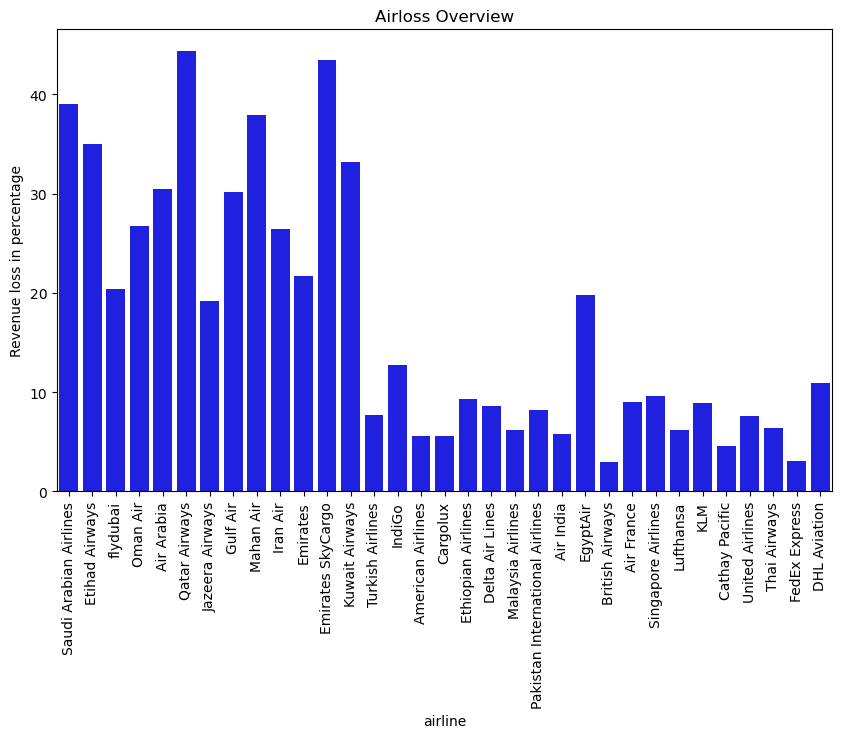

In [313]:
#Data Overview

#Airloss DataOverview

plt.figure(figsize=(10,6))
sns.barplot(airline_losses["revenue_loss_pct"],color = "blue")
plt.xticks(rotation = 90)
plt.ylabel("Revenue loss in percentage")
plt.title("Airloss Overview")
plt.show()


C:\Users\ramya\AppData\Local\Temp\ipykernel_49124\3352729004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=airport_disruption["region"],


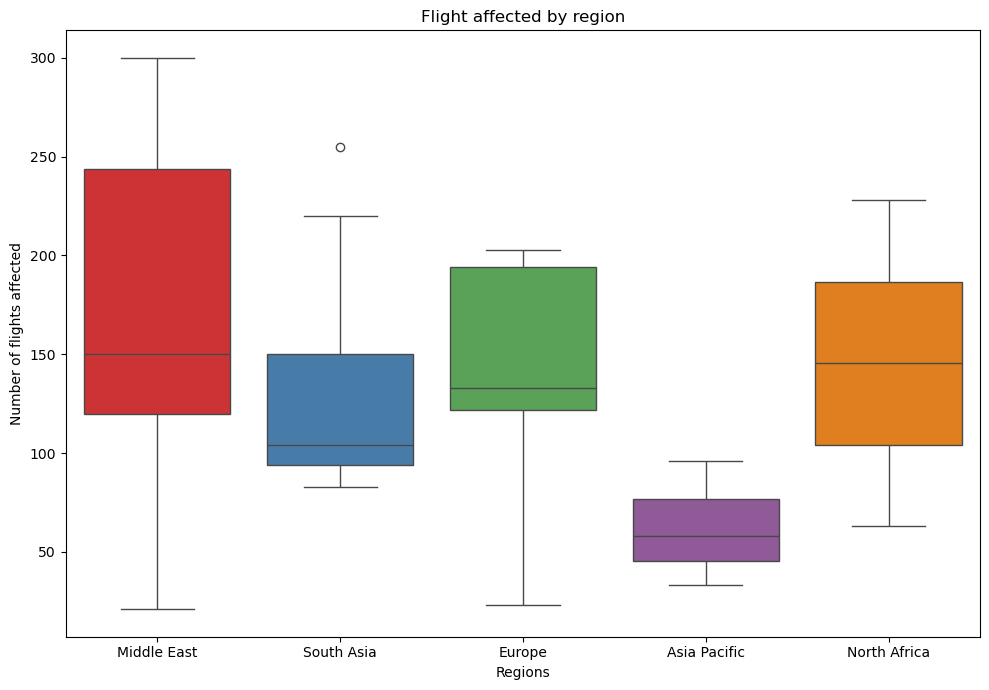

In [314]:
#Airport Disruption data overview 
plt.figure(figsize = (10,7))
sns.boxplot(x=airport_disruption["region"],
            y=airport_disruption["flights_affected"],
            palette="Set1")
plt.title("Flight affected by region")
plt.xlabel("Regions")
plt.ylabel("Number of flights affected")
plt.tight_layout()
plt.show()

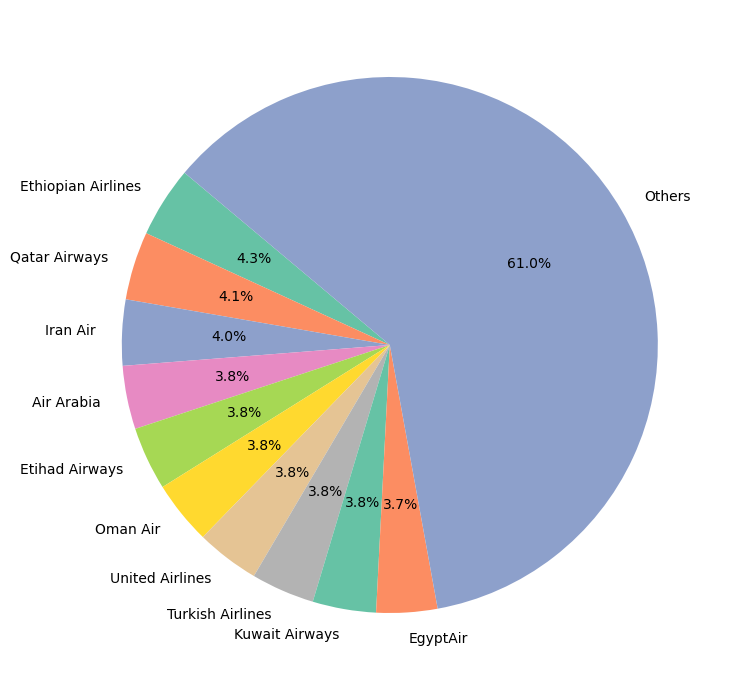

In [315]:
#Flight cancelled overview
airline_counts = flight_cancellation['airline'].value_counts()
n_top = 10
top_airlines = airline_counts.head(n_top)
other_sum = airline_counts[n_top:].sum()
labels = list(top_airlines.index) + ['Others']
sizes = list(top_airlines.values) + [other_sum]
plt.figure(figsize=(10,7))
plt.pie(sizes,labels = labels,autopct='%1.1f%%',startangle=140, colors = plt.cm.Set2.colors)
plt.tight_layout()
plt.show()

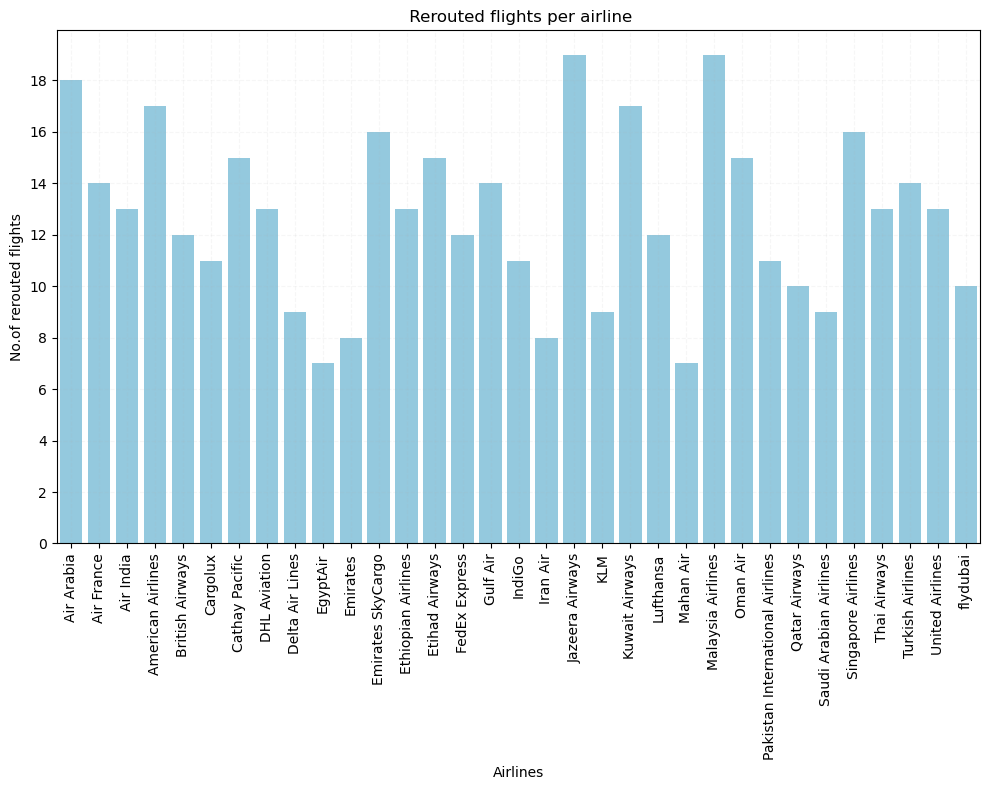

In [316]:
# flight-reroute overview:

rerouted_flights = flight_reroutes.groupby("airline")["flight_number"].count()
rerouted_flights = rerouted_flights.astype(int)
plt.figure(figsize=(10,8))
sns.barplot(x= rerouted_flights.index,y= rerouted_flights.values,color ='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Airlines")
plt.ylabel("No.of rerouted flights")
plt.title(" Rerouted flights per airline")
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.grid(axis='both',linestyle="--",alpha = 0.1)
plt.tight_layout()
plt.show()

In [317]:
#conflict_event overview:

# Group by location and get the most frequent (mode) severity per location
country_severity = conflict_events.groupby('location')['severity'].agg(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]).reset_index()

# Custom color mapping for severity categories
color_discrete_map = {
    'Low': '#FFE5E5',        # very light red (almost pink)
    'Medium': '#FF9999',     # light red
    'High': '#FF4D4D',       # medium red
    'Very High': '#CC0000',  # strong red
    'Critical': '#660000'    # indigo (very dark)
}

# Ensure severity is string (if not already)
country_severity['severity'] = country_severity['severity'].astype(str)

fig = px.choropleth(
    country_severity,
    locations='location',
    locationmode='country names',
    color='severity',
    color_discrete_map=color_discrete_map,
    title='Severity Zones by Country',
    # You can adjust other options as needed
    hover_name='location',
    hover_data=['severity'],
    # scope='world',
    # projection='natural earth',
    # template='plotly_white',
    # etc.
    # See Plotly Express documentation for more options
)
fig.show()

C:\Users\ramya\AppData\Local\Temp\ipykernel_49124\3152523893.py:18: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


C:\Users\ramya\AppData\Local\Temp\ipykernel_49124\1444513651.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0, 0].set_xticklabels(airline_losses.index, rotation=90)
C:\Users\ramya\AppData\Local\Temp\ipykernel_49124\1444513651.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=airport_disruption["region"], y=airport_disruption["flights_affected"], palette="Set1", ax=axs[0, 1])
C:\Users\ramya\AppData\Local\Temp\ipykernel_49124\1444513651.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_xticklabels(rerouted_flights.index, rotation=90)


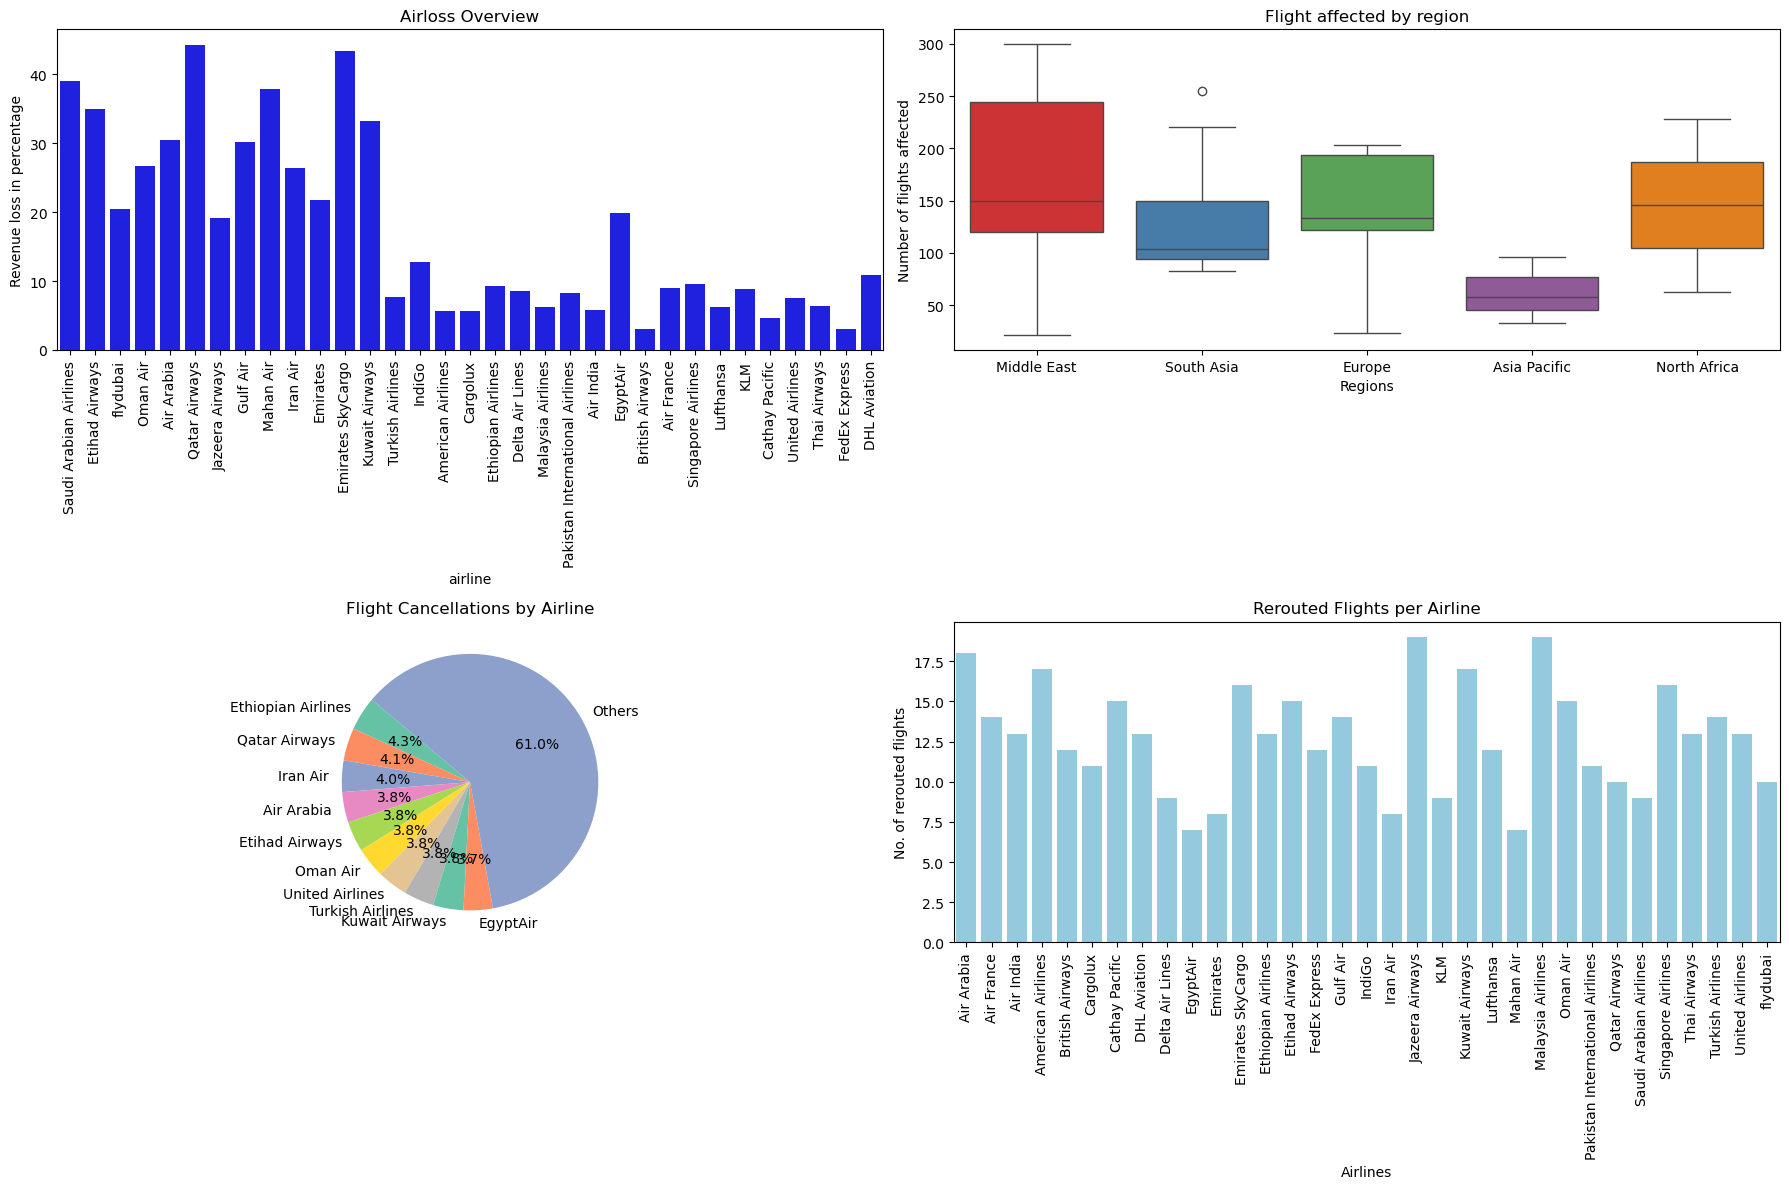

In [318]:
# Combined Data Overview: 4 Subplots in One Figure
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 2, figsize=(18, 12))

# 1. Airloss DataOverview (Barplot of revenue_loss_pct)
sns.barplot(y=airline_losses["revenue_loss_pct"], x=airline_losses.index, color="blue", ax=axs[0, 0])
axs[0, 0].set_xticklabels(airline_losses.index, rotation=90)
axs[0, 0].set_ylabel("Revenue loss in percentage")
axs[0, 0].set_title("Airloss Overview")

# 2. Airport Disruption (Boxplot by region)
sns.boxplot(x=airport_disruption["region"], y=airport_disruption["flights_affected"], palette="Set1", ax=axs[0, 1])
axs[0, 1].set_title("Flight affected by region")
axs[0, 1].set_xlabel("Regions")
axs[0, 1].set_ylabel("Number of flights affected")

# 3. Flight Cancelled (Pie chart of airline counts)
airline_counts = flight_cancellation['airline'].value_counts()
n_top = 10
top_airlines = airline_counts.head(n_top)
other_sum = airline_counts[n_top:].sum()
labels = list(top_airlines.index) + ['Others']
sizes = list(top_airlines.values) + [other_sum]
axs[1, 0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set2.colors)
axs[1, 0].set_title("Flight Cancellations by Airline")

# 4. Flight Reroute (Barplot of rerouted flights per airline)
rerouted_flights = flight_reroutes.groupby("airline")["flight_number"].count().astype(int)
sns.barplot(x=rerouted_flights.index, y=rerouted_flights.values, color='skyblue', ax=axs[1, 1])
axs[1, 1].set_xticklabels(rerouted_flights.index, rotation=90)
axs[1, 1].set_xlabel("Airlines")
axs[1, 1].set_ylabel("No. of rerouted flights")
axs[1, 1].set_title("Rerouted Flights per Airline")

plt.tight_layout()
plt.show()

Heatmap: Airline Cancellations vs. Reason


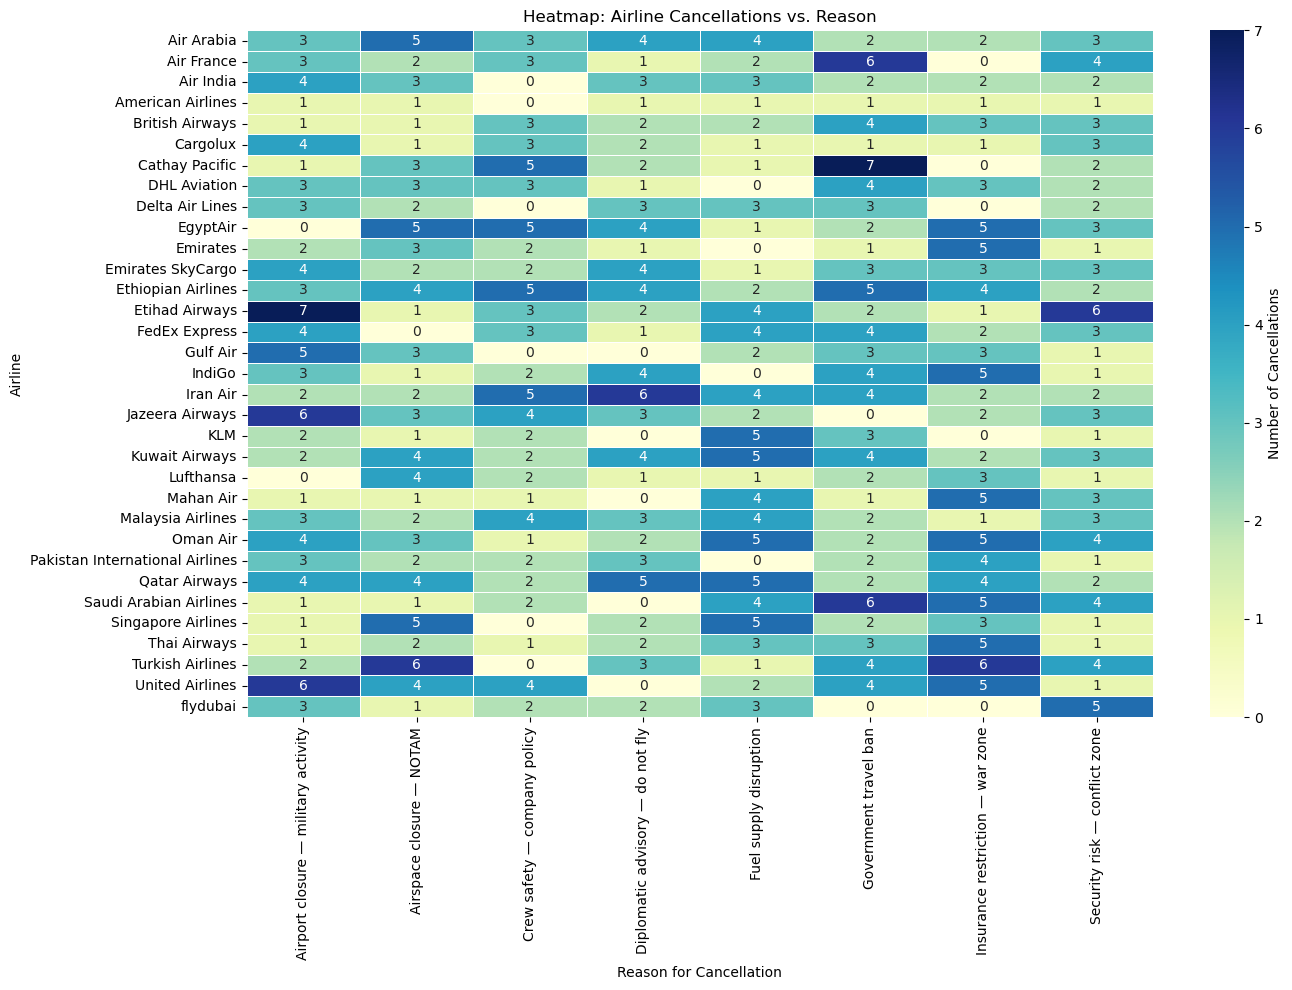

Flight cancellation on the war dates


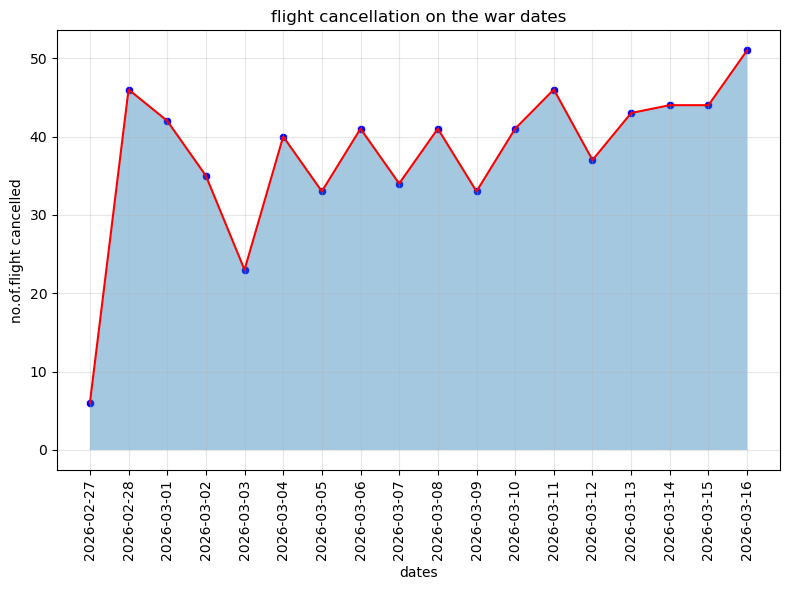

In [319]:
from IPython.display import display, Markdown, HTML
print("="*200)
print("Heatmap: Airline Cancellations vs. Reason")
print("="*200)
# Create a heatmap for airline cancellations vs reason
if 'reason' in flight_cancellation.columns:
    pivot_table = pd.pivot_table(
        flight_cancellation,
        values='flight_number',
        index='airline',
        columns='reason',
        aggfunc='count',
        fill_value=0
    )
    plt.figure(figsize=(14,10))
    # Revert to the previous color map: 'YlGnBu'
    sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Number of Cancellations'})
    plt.title('Heatmap: Airline Cancellations vs. Reason')
    plt.xlabel('Reason for Cancellation')
    plt.ylabel('Airline')
    plt.tight_layout()
    plt.show()
else:
    print("Column 'reason' not found in flight_cancellation.")

print("="*200)
print("Flight cancellation on the war dates")
print("="*200)
# No of cancelled flight on war dates
cancelled_flight = flight_cancellation.groupby('date')['flight_number'].count()

# line graph represent the flight cancellation
plt.figure(figsize=(8,6))
sns.lineplot(x=cancelled_flight.index, y = cancelled_flight.values, color="red")
sns.scatterplot(x=cancelled_flight.index, y = cancelled_flight.values, color ="blue")
plt.fill_between(cancelled_flight.index,cancelled_flight.values, alpha=0.4)
plt.grid(True, alpha=0.3)
plt.xticks(rotation = 90)
plt.xlabel("dates")
plt.ylabel("no.of.flight cancelled")
plt.title("flight cancellation on the war dates")
plt.tight_layout()
plt.show()


In [320]:
print("="*200)
print("KPI dashboard for flight cancellation")
print("="*200)

# --- KPI Dashboard: Total Cancellations and Passengers Affected ---
total_cancellations = flight_cancellation['flight_number'].nunique()

#Total passengers affected

if 'passengers_affected' in flight_cancellation.columns:
    total_passengers_affected = flight_cancellation["passengers_affected"].sum()
else:
    total_passengers_affected = None

# Display as KPI cards
kpi_md = f"""
<div style='display:flex; gap:40px;'>
  <div style='background:#e3f2fd; padding:20px; border-radius:10px; min-width:220px; text-align:center;'>
    <h2 style='color:#1976d2;'>✈️ Total Cancellations</h2>
    <p style='font-size:2em; color:#0d47a1; margin:0;'>{total_cancellations:,}</p>
  </div>
  <div style='background:#fce4ec; padding:20px; border-radius:10px; min-width:220px; text-align:center;'>
    <h2 style='color:#c2185b;'>👥 Passengers Affected</h2>
    <p style='font-size:2em; color:#880e4f; margin:0;'>{total_passengers_affected:,}</p>
  </div>
</div>
"""
display(HTML(kpi_md))

KPI dashboard for flight cancellation


Flights Cancelled and Passengers Affected per Airline


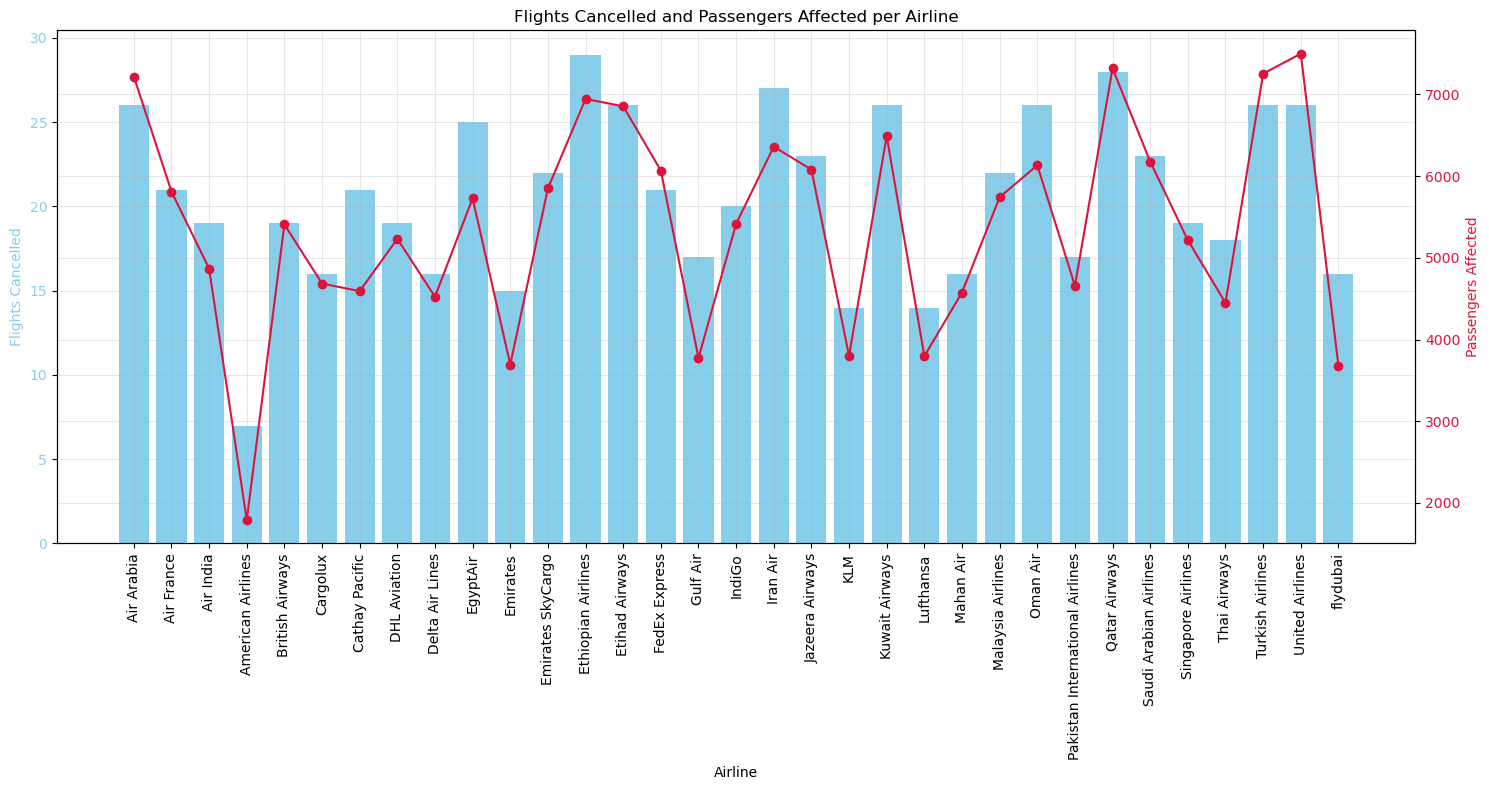

In [321]:
print("="*200)
print("Flights Cancelled and Passengers Affected per Airline")
print("="*200)

#cancelled flights vs passenger affected for each airlines

#calculating flight cancelled per airlines
cancelled_flight = flight_cancellation.groupby('airline')['flight_number'].count().reset_index(name='cancelled_flights')

#calculating passenger affected per airlines
passenger_affect = flight_cancellation.groupby('airline')['passengers_affected'].sum().reset_index(name='passengers_affected')

#airline_summary

airline_summary = pd.merge(cancelled_flight, passenger_affect, on='airline')

fig, ax1 = plt.subplots(figsize=(15,8))

# Bar plot for flights cancelled
ax1.bar(airline_summary['airline'], airline_summary['cancelled_flights'], color='skyblue', label='Flights Cancelled')
ax1.set_xlabel('Airline')
ax1.set_ylabel('Flights Cancelled', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
plt.xticks(rotation=90)

# Second y-axis for passengers affected
ax2 = ax1.twinx()
ax2.plot(airline_summary['airline'], airline_summary['passengers_affected'], color='crimson', marker='o', label='Passengers Affected')
ax2.set_ylabel('Passengers Affected', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Flights Cancelled and Passengers Affected per Airline')
ax1.grid(True,axis='both',alpha=0.3)
ax2.grid(True,axis='both',alpha=0.3)
plt.tight_layout()
plt.show()

Flight Cancellations by Country (Origin vs Destination)


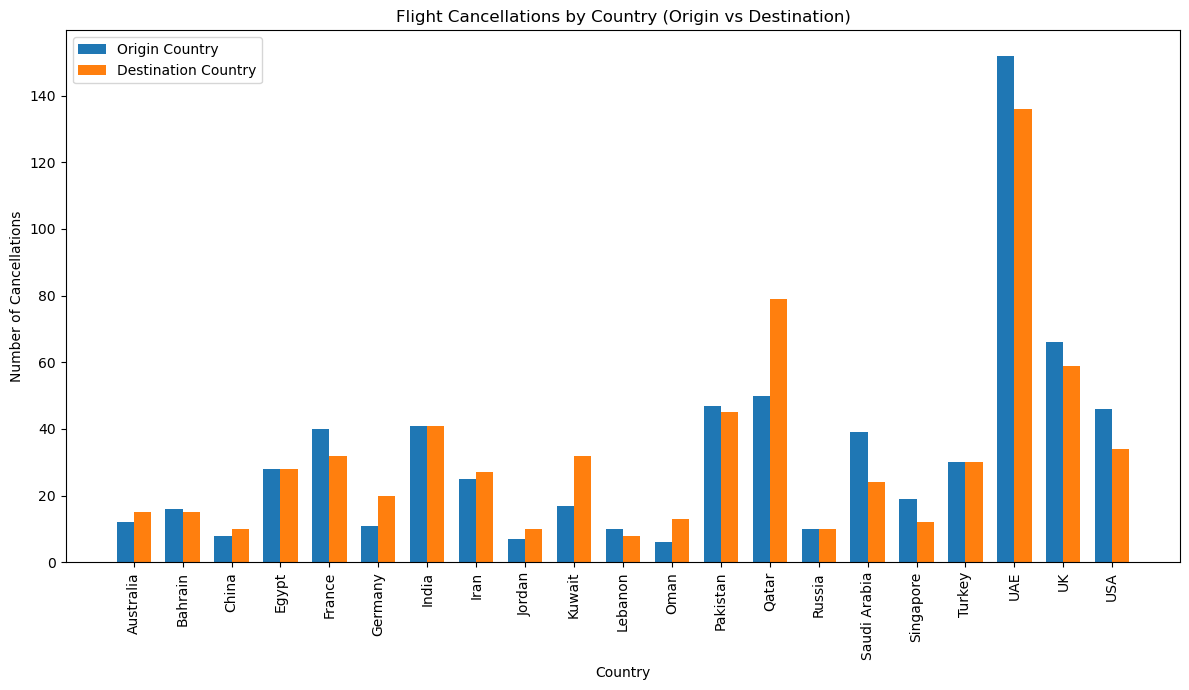

In [322]:
print("="*200)
print("Flight Cancellations by Country (Origin vs Destination)")
print("="*200)


# Side-by-side bar chart for origin and destination country cancellations
import numpy as np

# Recompute country-level counts from flight_cancellation to avoid column-name mismatches
origin_country_counts = (
    flight_cancellation.groupby('origin_country')['flight_number']
    .count()
    .reset_index(name='origin_count')
)

destination_country_counts = (
    flight_cancellation.groupby('destination_country')['flight_number']
    .count()
    .reset_index(name='destination_count')
)

countries = list(
    set(origin_country_counts['origin_country']).union(
        set(destination_country_counts['destination_country'])
    )
)
countries.sort()

origin_counts = (
    origin_country_counts.set_index('origin_country')
    .reindex(countries, fill_value=0)['origin_count']
)
destination_counts = (
    destination_country_counts.set_index('destination_country')
    .reindex(countries, fill_value=0)['destination_count']
)

x = np.arange(len(countries))  # label locations
width = 0.35  # width of the bars
plt.figure(figsize=(12,7))
plt.bar(x - width/2, origin_counts, width, label='Origin Country')
plt.bar(x + width/2, destination_counts, width, label='Destination Country')
plt.xticks(x, countries, rotation=90)
plt.xlabel('Country')
plt.ylabel('Number of Cancellations')
plt.title('Flight Cancellations by Country (Origin vs Destination)')
plt.legend()
plt.tight_layout()
plt.show()

In [323]:
print("="*200)
print("Flight Cancellations top 10 routes")
print("="*200)

# flight cancellation for each origin
origin_count = flight_cancellation.groupby('origin')['flight_number'].count().reset_index(name='origin_count')
# flight cancellation for each destination
destination_count = flight_cancellation.groupby('destination')['flight_number'].count().reset_index(name='destination_count')

# calculating flight cancellation for origin and destination
origin_destination = pd.merge(origin_count, destination_count, left_on='origin', right_on='destination', how='outer')

# Map Flow (Sankey) for Top 15 Routes by Cancellation Count with Different Colors
import plotly.graph_objects as go
import plotly.colors as pc

# Prepare data: top 15 most affected routes
route_counts = (
    flight_cancellation.groupby(['origin', 'destination'])['flight_number']
    .count()
    .reset_index(name='cancellation_count')
    .sort_values(by='cancellation_count', ascending=False)
)
top_routes = route_counts.head(15)

# Create unique list of airports for node labels
unique_airports = list(set(top_routes['origin']).union(set(top_routes['destination'])))
label_index = {airport: idx for idx, airport in enumerate(unique_airports)}

# Sankey diagram source, target, value
sources = top_routes['origin'].map(label_index)
targets = top_routes['destination'].map(label_index)
values = top_routes['cancellation_count']

# Assign a different color for each route
route_colors = pc.qualitative.Plotly * ((len(top_routes) // len(pc.qualitative.Plotly)) + 1)
link_colors = route_colors[:len(top_routes)]

fig = go.Figure(data=[
    go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=unique_airports,
            color="blue"
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors
        )
    )
])

fig.update_layout(title_text="Top 15 Most Affected Flight Routes (Cancellations) - Flow Map (Colored Routes)", font_size=12)
fig.show()

Flight Cancellations top 10 routes


Average passengers affected per cancelled flight (overall): 261.67


C:\Users\ramya\AppData\Local\Temp\ipykernel_49124\1474533969.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  airline_avg = flight_cancellation.groupby('airline').apply(lambda df: df['passengers_affected'].sum() / df['flight_number'].nunique()).reset_index(name='avg_passengers_per_cancel')


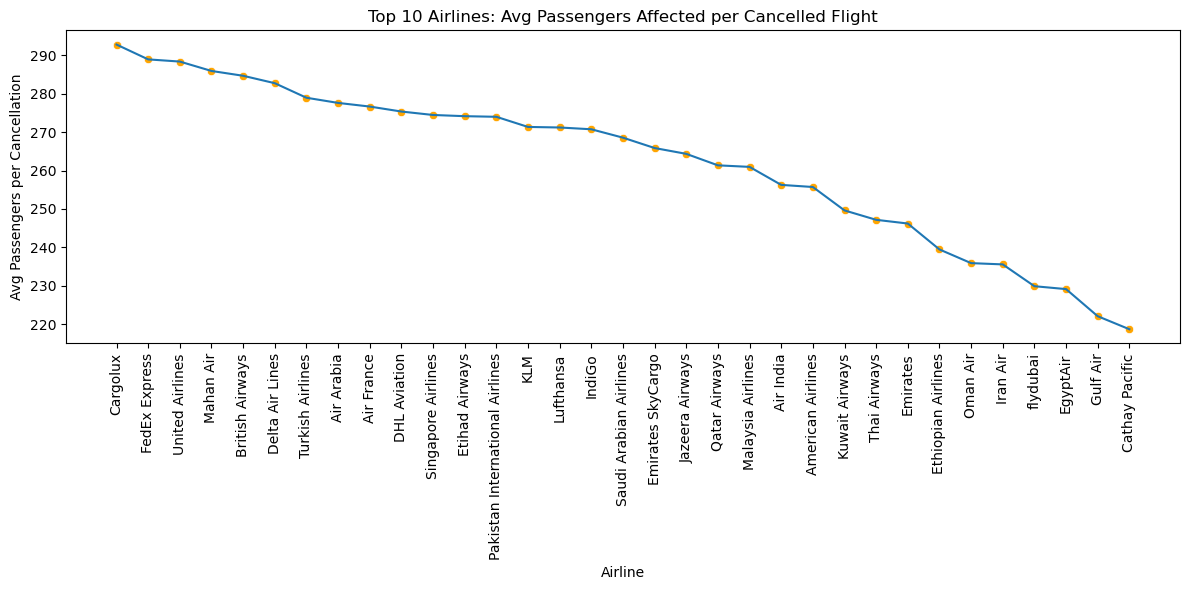

In [324]:
# Calculate average passengers affected per cancellation (overall)
if 'passengers_affected' in flight_cancellation.columns:
    avg_passengers_per_cancel = flight_cancellation['passengers_affected'].sum() / flight_cancellation['flight_number'].nunique()
    print(f"Average passengers affected per cancelled flight (overall): {avg_passengers_per_cancel:.2f}")
else:
    print("Column 'passengers_affected' not found in flight_cancellation.")

# Average passengers affected per cancellation by airline
if 'passengers_affected' in flight_cancellation.columns:
    airline_avg = flight_cancellation.groupby('airline').apply(lambda df: df['passengers_affected'].sum() / df['flight_number'].nunique()).reset_index(name='avg_passengers_per_cancel')
    #display(airline_avg.sort_values('avg_passengers_per_cancel', ascending=False),airline_avg.head(10))
    
    # Visualization
    plt.figure(figsize=(12,6))
    sns.lineplot(x='airline', y='avg_passengers_per_cancel', data=airline_avg.sort_values('avg_passengers_per_cancel', ascending=False))
    sns.scatterplot(
        x='airline',
        y='avg_passengers_per_cancel',
        data=airline_avg.sort_values('avg_passengers_per_cancel', ascending=False),
        color='orange'
    )
    plt.xticks(rotation=90)
    plt.ylabel('Avg Passengers per Cancellation')
    plt.xlabel('Airline')
    plt.title('Top 10 Airlines: Avg Passengers Affected per Cancelled Flight')
    plt.tight_layout()
    plt.show()
else:
    print("Column 'passengers_affected' not found in flight_cancellation.")

#### Machine Learning Prediction:

#### predicting Airloss using operational disruption 

### Model pipeline

* Data preprocession (e.g., handling missing values, scaling, encoding categorical variables)
* Feature selection or extraction
* Model Training (fitting a machine learning algorithm)
* Model Evaluation (testing performance on new data)

### Summary: What This Analysis Demonstrates

- **Data-Driven Insights:**
  - Shows how operational disruptions (cancellations, reroutes, fuel costs, passengers impacted) affect airline financial losses.
  - Highlights differences in disruption and loss patterns by country or airline type.

- **Predictive Modeling:**
  - Demonstrates the use of machine learning to accurately predict estimated daily losses for airlines.
  - Compares multiple regression models and their performance.

- **Scenario Analysis ("What-if")**
  - Enables prediction of losses for new or hypothetical situations, supporting planning and risk assessment.

- **Feature Importance:**
  - Identifies which factors most influence losses, guiding decision-making and risk management.

- **Visualization:**
  - Provides clear, comparative visualizations of disruptions and losses across airlines, regions, and event types.

- **Business Value:**
  - Supports strategic planning, resource allocation, and mitigation strategies for airlines and regulators.
  - Demonstrates the value of data science in operational and financial decision-making.


#### Note on Scaling

When using `StandardScaler` (or any scaler), always use `fit_transform` on the training set and only `transform` on the test set. This ensures the scaling is based only on the training data and prevents data leakage.

In [325]:
# step : preprocessing the categorical data
#read csv file 
airline_loss_estimate = pd.read_csv(base_file+'airline_losses_estimate.csv')
# selecting data for preprocessing 
categorical_col = ['airline']



preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),categorical_col)
    ],
    remainder='passthrough'
 )


# Feature Selection

x = airline_loss_estimate[['cancelled_flights','rerouted_flights','additional_fuel_cost_usd','passengers_impacted','airline']]
y=airline_loss_estimate['estimated_daily_loss_usd']


# model splitting
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Fit the preprocessor on training data and transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#Scale festure
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_processed)  # fit only on training data
X_test_scaled = scaler.transform(X_test_processed)  # Transform test data with same scaler

# Training multiple models to pick the best_model

models = {
    'Linear Regression' : LinearRegression(),
    'RandomForest Regressor' : RandomForestRegressor(n_estimators=100,random_state=42),
    'DecisionTree Regressor' : DecisionTreeRegressor(random_state=42),
    'GradientBoosting Regressor': GradientBoostingRegressor(random_state=42)
}

result =[]

for name, model in models.items():
    #fit the model
    model.fit(X_train_scaled,Y_train)
    #prediction
    Y_pred = model.predict(X_test_scaled)
    #evaluating the models
    mse = mean_squared_error(Y_test,Y_pred)
    rsq = r2_score(Y_test,Y_pred)
    result.append({'Model': name, 'MSE': np.sqrt(mse), 'R2':rsq})

result_df = pd.DataFrame(result)
display(result_df)

,Model,MSE,R2
0,Linear Regression,289025.183612,0.305689
1,RandomForest Regressor,86543.217940,0.937749
2,DecisionTree Regressor,87177.978871,0.936832
3,GradientBoosting Regressor,77189.073860,0.950478


### What-if Scenario Prediction Example

You can use your trained model to estimate losses for any new or hypothetical situation. This is called a "what-if" or scenario analysis. For example, you might want to know:

- What would the estimated daily loss be if an airline in the UAE had 10 cancelled flights, 5 rerouted flights, $20,000 additional fuel cost, and 150 passengers impacted?

Below is an example code cell to perform such a prediction. Change the values to match any scenario you want to test.

In [326]:
# Example: Predicting for a What-if Scenario
# Replace the values below with your new or hypothetical scenario
new_data = pd.DataFrame([{
    'cancelled_flights': 2,
    'rerouted_flights': 6,
    'additional_fuel_cost_usd': 8000,
    'passengers_impacted': 1080,
    'airline': 'Oman Air'
}])

# Apply the same preprocessing and scaling
new_data_processed = preprocessor.transform(new_data)
new_data_scaled = scaler.transform(new_data_processed)

# Use your best model (e.g., GradientBoosting Regressor)
predicted_loss = models['GradientBoosting Regressor'].predict(new_data_scaled)
print(f'Predicted estimated daily loss (USD): {predicted_loss[0]:,.2f}')

Predicted estimated daily loss (USD): 429,688.00
